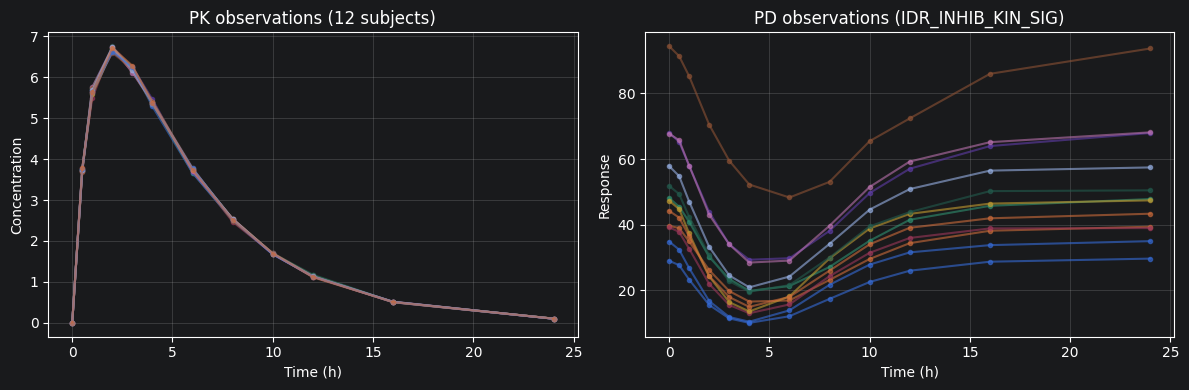

Active model: IDR_INHIB_KIN_SIG
Config family: idr
TV PD: {'Kin': 25.0, 'Kout': 0.5, 'Imax': 1.0, 'Smax': 0.0, 'EC50': 4.0, 'gamma': 3.0, 'E0': 0.0, 'S': 0.0, 'Emax': 0.0, 'ke0': 0.0}
Omega PD: {'Kin': 0.25, 'Kout': 0.2, 'Imax': 0.0, 'Smax': 0.0, 'EC50': 0.0, 'gamma': 0.2, 'E0': 0.0, 'S': 0.0, 'Emax': 0.0, 'ke0': 0.0}

pop_data shape = (144, 4) (rows=12*12)
X torch.Size([144, 1]), Y torch.Size([144, 1]), C_known torch.Size([144, 1]), ID torch.Size([144, 1])

First 3 sampled individual params:
  ID 0: E0=0.000, Emax=0.000, EC50=4.000, gamma=2.863, ke0=0.000, Kin=23.579, Kout=0.686, Imax=1.000, Smax=0.000
  ID 1: E0=0.000, Emax=0.000, EC50=4.000, gamma=3.128, ke0=0.000, Kin=15.317, Kout=0.383, Imax=1.000, Smax=0.000
  ID 2: E0=0.000, Emax=0.000, EC50=4.000, gamma=3.225, ke0=0.000, Kin=21.276, Kout=0.537, Imax=1.000, Smax=0.000

Empirical IIV (log-SD where >0):
  E0: N/A
  S: N/A
  Emax: N/A
  EC50: 0.000
  gamma: 0.141
  ke0: N/A
  Kin: 0.203
  Kout: 0.258
  Imax: 0.000
  Smax: N/A


In [1]:
# ============================
# Cell 1 (Comprehensive PD model registry + data generator)
# 覆盖主流PD：Direct / Biophase / IDR(+drug modulation)
# ============================
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.interpolate import interp1d
import pandas as pd

# ----------------------------
# 0) 全局设置
# ----------------------------
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)

n_subjects = 12
t_dense = np.linspace(0, 24, 241)
t_obs = np.array([0, 0.5, 1, 2, 3, 4, 6, 8, 10, 12, 16, 24], dtype=float)

pk_noise_cv = 0.01
pd_noise_cv = 0.01

# PK典型参数（单次口服Bateman）
tv_pk = dict(D=100.0, F=1.0, V=10.0, ka=1.0, ke=0.2)
omega_pk = dict(V=0.00, ka=0.00, ke=0.00)

# ----------------------------
# 1) 主流PD模型注册表
# 分类：
# A. Direct
# B. Biophase (effect-compartment)
# C. IDR base
# D. IDR + modulation (nested)
# ----------------------------
MODEL_REGISTRY = {
    # ===== A) Direct effect =====
    "DIRECT_LINEAR": {
        "family": "direct",
        "effect_form": "linear",  # E = S*C
        "tv_pd": dict(E0=50.0, S=1.5, Emax=0.0, EC50=4.0, gamma=1.0, ke0=0.0, Kin=0.0, Kout=0.0),
        "omega_pd": dict(E0=0.15, S=0.15, Emax=0.00, EC50=0.00, gamma=0.00, ke0=0.00, Kin=0.00, Kout=0.00),
    },
    "DIRECT_EMAX": {
        "family": "direct",
        "effect_form": "emax",  # E = E0 + Emax*C/(EC50+C)
        "tv_pd": dict(E0=50.0, S=0.0, Emax=30.0, EC50=4.0, gamma=1.0, ke0=0.0, Kin=0.0, Kout=0.0),
        "omega_pd": dict(E0=0.15, S=0.00, Emax=0.20, EC50=0.15, gamma=0.00, ke0=0.00, Kin=0.00, Kout=0.00),
    },
    "DIRECT_SIGEMAX": {
        "family": "direct",
        "effect_form": "sigemax",  # E = E0 + Emax*Hill(C)
        "tv_pd": dict(E0=50.0, S=0.0, Emax=30.0, EC50=4.0, gamma=3.0, ke0=0.0, Kin=0.0, Kout=0.0),
        "omega_pd": dict(E0=0.15, S=0.00, Emax=0.20, EC50=0.15, gamma=0.20, ke0=0.00, Kin=0.00, Kout=0.00),
    },

    # ===== B) Biophase =====
    "BIOPHASE_EMAX": {
        "family": "biophase",
        "effect_form": "emax",  # Ce from dCe/dt=ke0(C-Ce), then E(Ce)
        "tv_pd": dict(E0=50.0, S=0.0, Emax=30.0, EC50=4.0, gamma=1.0, ke0=0.8, Kin=0.0, Kout=0.0),
        "omega_pd": dict(E0=0.15, S=0.00, Emax=0.20, EC50=0.15, gamma=0.00, ke0=0.20, Kin=0.00, Kout=0.00),
    },
    "BIOPHASE_SIGEMAX": {
        "family": "biophase",
        "effect_form": "sigemax",
        "tv_pd": dict(E0=50.0, S=0.0, Emax=30.0, EC50=4.0, gamma=3.0, ke0=0.8, Kin=0.0, Kout=0.0),
        "omega_pd": dict(E0=0.15, S=0.00, Emax=0.20, EC50=0.15, gamma=0.20, ke0=0.20, Kin=0.00, Kout=0.00),
    },

    # ===== C) IDR base =====
    "IDR_BASE": {
        "family": "idr",
        "idr_mode": "base",  # dR=Kin-Kout*R
        "mod_target": "none",
        "mod_type": "none",
        "tv_pd": dict(Kin=25.0, Kout=0.5, Imax=0.0, Smax=0.0, EC50=4.0, gamma=1.0, E0=0.0, S=0.0, Emax=0.0, ke0=0.0),
        "omega_pd": dict(Kin=0.25, Kout=0.20, Imax=0.00, Smax=0.00, EC50=0.00, gamma=0.00, E0=0.00, S=0.00, Emax=0.00, ke0=0.00),
    },

    # ===== D) IDR + modulation (nested) =====
    # Kin inhibition by sigmoid Emax: dR=Kin*(1-Imax*Hill)-Kout*R
    "IDR_INHIB_KIN_SIG": {
        "family": "idr",
        "idr_mode": "modulated",
        "mod_target": "Kin",
        "mod_type": "inhib_sigmoid",
        "tv_pd": dict(Kin=25.0, Kout=0.5, Imax=1.0, Smax=0.0, EC50=4.0, gamma=3.0, E0=0.0, S=0.0, Emax=0.0, ke0=0.0),
        "omega_pd": dict(Kin=0.25, Kout=0.20, Imax=0.00, Smax=0.00, EC50=0.00, gamma=0.20, E0=0.00, S=0.00, Emax=0.00, ke0=0.00),
    },
    # Kin stimulation by sigmoid Emax: dR=Kin*(1+Smax*Hill)-Kout*R
    "IDR_STIM_KIN_SIG": {
        "family": "idr",
        "idr_mode": "modulated",
        "mod_target": "Kin",
        "mod_type": "stim_sigmoid",
        "tv_pd": dict(Kin=25.0, Kout=0.5, Imax=0.0, Smax=1.0, EC50=4.0, gamma=2.5, E0=0.0, S=0.0, Emax=0.0, ke0=0.0),
        "omega_pd": dict(Kin=0.25, Kout=0.20, Imax=0.00, Smax=0.15, EC50=0.00, gamma=0.20, E0=0.00, S=0.00, Emax=0.00, ke0=0.00),
    },
    # Kout stimulation by sigmoid Emax: dR=Kin-Kout*(1+Imax*Hill)*R
    "IDR_INHIB_KOUT_SIG": {
        "family": "idr",
        "idr_mode": "modulated",
        "mod_target": "Kout",
        "mod_type": "stim_sigmoid",
        "tv_pd": dict(Kin=25.0, Kout=0.5, Imax=1.0, Smax=0.0, EC50=4.0, gamma=2.5, E0=0.0, S=0.0, Emax=0.0, ke0=0.0),
        "omega_pd": dict(Kin=0.25, Kout=0.20, Imax=0.00, Smax=0.00, EC50=0.00, gamma=0.20, E0=0.00, S=0.00, Emax=0.00, ke0=0.00),
    },
    # Kout inhibition by sigmoid Emax: dR=Kin-Kout*(1-Smax*Hill)*R
    "IDR_STIM_KOUT_SIG": {
        "family": "idr",
        "idr_mode": "modulated",
        "mod_target": "Kout",
        "mod_type": "inhib_sigmoid",
        "tv_pd": dict(Kin=25.0, Kout=0.5, Imax=0.0, Smax=0.8, EC50=4.0, gamma=2.5, E0=0.0, S=0.0, Emax=0.0, ke0=0.0),
        "omega_pd": dict(Kin=0.25, Kout=0.20, Imax=0.00, Smax=0.15, EC50=0.00, gamma=0.20, E0=0.00, S=0.00, Emax=0.00, ke0=0.00),
    },
}

# 当前活动模型（后续循环探索时改这里）
ACTIVE_MODEL = "IDR_INHIB_KIN_SIG"

# ----------------------------
# 2) 公共函数
# ----------------------------
def hill(C, EC50, gamma):
    C = max(float(C), 1e-10)
    return (C**gamma) / (EC50**gamma + C**gamma)

def emx(C, Emax, EC50):
    C = max(float(C), 1e-10)
    return Emax * C / (EC50 + C)

def sample_individual_params(tv_pk, omega_pk, tv_pd, omega_pd):
    p = {}

    # PK
    p["D"] = tv_pk["D"]; p["F"] = tv_pk["F"]
    p["V"]  = tv_pk["V"]  * np.exp(np.random.normal(0, omega_pk["V"]))
    p["ka"] = tv_pk["ka"] * np.exp(np.random.normal(0, omega_pk["ka"]))
    p["ke"] = tv_pk["ke"] * np.exp(np.random.normal(0, omega_pk["ke"]))
    if abs(p["ka"] - p["ke"]) < 1e-3:
        p["ka"] = p["ke"] + 1e-3

    # PD (统一字段)
    keys = ["E0","S","Emax","EC50","gamma","ke0","Kin","Kout","Imax","Smax"]
    for k in keys:
        base = tv_pd.get(k, 0.0)
        om = omega_pd.get(k, 0.0)
        p[k] = base * np.exp(np.random.normal(0, om)) if base > 0 else 0.0

    # bounds
    p["EC50"] = max(p["EC50"], 1e-3)
    p["gamma"] = np.clip(max(p["gamma"], 1e-3), 0.3, 8.0)
    p["ke0"] = max(p["ke0"], 1e-4) if p["ke0"] > 0 else 0.0
    p["Kin"] = max(p["Kin"], 1e-4) if p["Kin"] > 0 else 0.0
    p["Kout"] = max(p["Kout"], 1e-4) if p["Kout"] > 0 else 0.0
    p["Imax"] = np.clip(p["Imax"], 0.0, 1.5)
    p["Smax"] = np.clip(p["Smax"], 0.0, 2.0)
    return p

def simulate_subject(cfg, p):
    """根据模型配置与个体参数，返回观测点 C_obs, R_obs"""
    # PK concentration
    pre = (p["F"] * p["D"] * p["ka"]) / (p["V"] * (p["ka"] - p["ke"]))
    C_dense = pre * (np.exp(-p["ke"] * t_dense) - np.exp(-p["ka"] * t_dense))
    C_dense = np.clip(C_dense, 0.0, None)
    C_func = interp1d(t_dense, C_dense, kind="cubic", fill_value="extrapolate")

    fam = cfg["family"]
    eff = cfg.get("effect_form", None)

    if fam == "direct":
        # 直接效应：R其实是E(t)
        E0 = p["E0"]
        if eff == "linear":
            E_dense = E0 + p["S"] * C_dense
        elif eff == "emax":
            E_dense = E0 + np.array([emx(c, p["Emax"], p["EC50"]) for c in C_dense])
        elif eff == "sigemax":
            E_dense = E0 + p["Emax"] * np.array([hill(c, p["EC50"], p["gamma"]) for c in C_dense])
        else:
            raise ValueError(f"Unknown direct effect_form: {eff}")
        R_dense = E_dense

    elif fam == "biophase":
        # 状态变量 [Ce, E]
        E0 = p["E0"]
        ke0 = p["ke0"]

        def rhs(z, t):
            Ce, E = z
            C_t = float(C_func(t))
            dCe = ke0 * (C_t - Ce)

            if eff == "emax":
                E_inf = E0 + emx(Ce, p["Emax"], p["EC50"])
            elif eff == "sigemax":
                E_inf = E0 + p["Emax"] * hill(Ce, p["EC50"], p["gamma"])
            else:
                raise ValueError(f"Unknown biophase effect_form: {eff}")

            # 这里用一阶逼近到瞬时效应（时间常数取1）
            dE = (E_inf - E)
            return [dCe, dE]

        z0 = [0.0, E0]
        z_dense = odeint(lambda z, tt: rhs(z, tt), z0, t_dense)
        R_dense = z_dense[:, 1]

    elif fam == "idr":
        mode = cfg.get("idr_mode", "base")
        target = cfg.get("mod_target", "none")
        mtype = cfg.get("mod_type", "none")

        def rhs(R, t):
            C_t = float(C_func(t))
            H = hill(C_t, p["EC50"], p["gamma"])
            Kin, Kout = p["Kin"], p["Kout"]

            if mode == "base":
                return Kin - Kout * R

            if target == "Kin":
                if mtype == "inhib_sigmoid":
                    Kin_eff = Kin * (1 - p["Imax"] * H)
                elif mtype == "stim_sigmoid":
                    Kin_eff = Kin * (1 + p["Smax"] * H)
                else:
                    raise ValueError(f"Unknown mod_type for Kin: {mtype}")
                return Kin_eff - Kout * R

            elif target == "Kout":
                if mtype == "stim_sigmoid":
                    Kout_eff = Kout * (1 + p["Imax"] * H)
                elif mtype == "inhib_sigmoid":
                    Kout_eff = Kout * (1 - p["Smax"] * H)
                else:
                    raise ValueError(f"Unknown mod_type for Kout: {mtype}")
                Kout_eff = max(Kout_eff, 1e-8)
                return Kin - Kout_eff * R

            else:
                raise ValueError(f"Unknown mod_target: {target}")

        R0 = p["Kin"] / p["Kout"]
        R_dense = odeint(lambda r, tt: rhs(r, tt), R0, t_dense).flatten()

    else:
        raise ValueError(f"Unknown family: {fam}")

    # Sample to observation + noise
    C_obs_clean = interp1d(t_dense, C_dense, kind="cubic")(t_obs)
    R_obs_clean = interp1d(t_dense, R_dense, kind="cubic")(t_obs)

    C_obs = C_obs_clean * (1.0 + np.random.normal(0, pk_noise_cv, size=t_obs.shape))
    R_obs = R_obs_clean * (1.0 + np.random.normal(0, pd_noise_cv, size=t_obs.shape))

    C_obs = np.clip(C_obs, 0.0, None)
    R_obs = np.clip(R_obs, 1e-8, None)
    return C_obs, R_obs

def generate_population_data(model_name, seed=42, n_subjects=12):
    cfg = MODEL_REGISTRY[model_name]
    tv_pd = cfg["tv_pd"]
    omega_pd = cfg["omega_pd"]

    np.random.seed(seed)
    torch.manual_seed(seed)

    all_rows = []
    subject_params = []

    for sid in range(n_subjects):
        p = sample_individual_params(tv_pk, omega_pk, tv_pd, omega_pd)
        p["model_name"] = model_name
        p["family"] = cfg["family"]
        subject_params.append(p)

        C_obs, R_obs = simulate_subject(cfg, p)
        for j, tt in enumerate(t_obs):
            all_rows.append([sid, tt, C_obs[j], R_obs[j]])

    pop_data = np.array(all_rows, dtype=float)
    return pop_data, subject_params, cfg

# ----------------------------
# 3) 生成活动模型数据
# ----------------------------
pop_data, subject_params, active_cfg = generate_population_data(
    model_name=ACTIVE_MODEL,
    seed=GLOBAL_SEED,
    n_subjects=n_subjects
)

# 组装后续训练变量（与你现有流程兼容）
X_np = pop_data[:, 1:2]
C_obs_np = pop_data[:, 2:3]
Y_np = pop_data[:, 3:4]
ID_np = pop_data[:, 0:1].astype(int)

X = torch.tensor(X_np, dtype=torch.float32)
Y = torch.tensor(Y_np, dtype=torch.float32)
C_known = torch.tensor(C_obs_np, dtype=torch.float32)
ID_tensor = torch.tensor(ID_np, dtype=torch.long)

# ----------------------------
# 4) 可视化
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for sid in range(n_subjects):
    idx = (ID_np[:, 0] == sid)
    axes[0].plot(X_np[idx, 0], C_obs_np[idx, 0], '.-', alpha=0.6)
    axes[1].plot(X_np[idx, 0], Y_np[idx, 0], '.-', alpha=0.6)

axes[0].set_title(f"PK observations ({n_subjects} subjects)")
axes[0].set_xlabel("Time (h)")
axes[0].set_ylabel("Concentration")
axes[0].grid(alpha=0.3)

axes[1].set_title(f"PD observations ({ACTIVE_MODEL})")
axes[1].set_xlabel("Time (h)")
axes[1].set_ylabel("Response")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ----------------------------
# 5) 输出检查
# ----------------------------
print(f"Active model: {ACTIVE_MODEL}")
print("Config family:", active_cfg["family"])
print("TV PD:", active_cfg["tv_pd"])
print("Omega PD:", active_cfg["omega_pd"])
print(f"\npop_data shape = {pop_data.shape} (rows={n_subjects}*{len(t_obs)})")
print(f"X {X.shape}, Y {Y.shape}, C_known {C_known.shape}, ID {ID_tensor.shape}")

print("\nFirst 3 sampled individual params:")
for i in range(min(3, n_subjects)):
    p = subject_params[i]
    print(f"  ID {i}: E0={p['E0']:.3f}, Emax={p['Emax']:.3f}, EC50={p['EC50']:.3f}, gamma={p['gamma']:.3f}, "
          f"ke0={p['ke0']:.3f}, Kin={p['Kin']:.3f}, Kout={p['Kout']:.3f}, Imax={p['Imax']:.3f}, Smax={p['Smax']:.3f}")

sp = pd.DataFrame(subject_params)
print("\nEmpirical IIV (log-SD where >0):")
for k in ["E0","S","Emax","EC50","gamma","ke0","Kin","Kout","Imax","Smax"]:
    vals = sp[k].values
    if np.all(vals > 0):
        print(f"  {k}: {np.std(np.log(vals), ddof=1):.3f}")
    else:
        print(f"  {k}: N/A")

In [2]:
# ============================
# Cell 2 (Generalizable FINAL): 稀疏发现 + Top-K(Validation BIC) + Hierarchy
# ============================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import grad
import copy

from deepymod import Library, DeepMoD
from deepymod.data import Dataset, get_train_test_loader

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ----------------------------
# 0) 全局超参数
# ----------------------------
n_epochs_warmup = 1800
n_epochs_prune = 700
max_prune_rounds = 10
stable_rounds_required = 2

lr_nn = 1e-3
lr_lib = 3e-4
lambda_reg = 0.2
lambda_gamma_pen = 1e-4
ridge_lam = 1e-4

rel_thr_main = 0.10
rel_thr_interaction = 0.15
min_terms_keep = 2

# Top-K配置
topk = 5
candidate_extra_terms_max = 2
candidate_refit_epochs = 400

# 训练/验证切分（用于Validation-BIC）
train_frac = 0.7

# ----------------------------
# 1) 数据准备（均值轨迹）
# ----------------------------
df_pop = pd.DataFrame(pop_data, columns=["sid", "time", "C_obs", "R_obs"])
agg = (df_pop.groupby("time", as_index=False)
            .agg(C_mean=("C_obs", "mean"), R_mean=("R_obs", "mean"))
            .sort_values("time")
            .reset_index(drop=True))

Xg = torch.tensor(agg["time"].values.reshape(-1,1), dtype=torch.float32)
Cg = torch.tensor(agg["C_mean"].values.reshape(-1,1), dtype=torch.float32)
Yg = torch.tensor(agg["R_mean"].values.reshape(-1,1), dtype=torch.float32)

Xn = (Xg - Xg.mean()) / (Xg.std() + 1e-8)
Yn = (Yg - Yg.mean()) / (Yg.std() + 1e-8)

X_all = torch.cat([Xn, Cg], dim=1).float()   # [t_norm, C]
Y_all = Yn.float()

N = X_all.shape[0]
n_train = int(np.floor(train_frac * N))
perm = np.arange(N)  # 时间序列保持顺序也可，这里用前70%训练
train_idx = perm[:n_train]
val_idx = perm[n_train:]

X_train, Y_train = X_all[train_idx], Y_all[train_idx]
X_val, Y_val = X_all[val_idx], Y_all[val_idx]

def data_loader_func_train():
    return X_train, Y_train

dataset = Dataset(
    data_loader_func_train,
    preprocess_kwargs=dict(noise_level=0.0, normalize_coords=False, normalize_data=False),
    device=device
)
train_loader, _ = get_train_test_loader(dataset, train_test_split=1.0)

# ----------------------------
# 2) 库与模型组件
# ----------------------------
class PDLibraryExpanded(Library):
    """
    0:1, 1:R, 2:C, 3:C^2, 4:Emax(C), 5:Hill(C), 6:C*R, 7:Emax(C)*R, 8:Hill(C)*R
    """
    def __init__(self):
        super().__init__()
        self.raw_ec50 = nn.Parameter(torch.tensor(4.0))
        self.raw_gamma = nn.Parameter(torch.tensor(2.0))

    def library(self, input):
        pred, data = input
        R = pred[:, 0:1]

        dR_ddata = grad(
            R, data,
            grad_outputs=torch.ones_like(R),
            create_graph=True,
            retain_graph=True
        )[0]
        dRdt = dR_ddata[:, 0:1]

        C = data[:, 1:2].clamp_min(1e-8)
        ec50 = F.softplus(self.raw_ec50) + 1e-8
        gamma = F.softplus(self.raw_gamma) + 1e-8

        emax = C / (ec50 + C)
        hill = (C**gamma) / (ec50**gamma + C**gamma)

        one = torch.ones_like(R)
        theta = torch.cat([one, R, C, C*C, emax, hill, C*R, emax*R, hill*R], dim=1)
        return [dRdt], [theta]

class TimeOnlyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        t = x[:, 0:1]
        pred = self.net(t)
        return pred, x

class FixedMaskEstimator(nn.Module):
    def __init__(self, init_mask):
        super().__init__()
        self.register_buffer("mask_buf", init_mask.clone())
    def set_mask(self, new_mask):
        self.mask_buf = new_mask.clone()
    def forward(self, thetas, time_derivs):
        return [self.mask_buf]

class RidgeConstraint(nn.Module):
    def __init__(self, lam=1e-4):
        super().__init__()
        self.lam = lam
        self.sparsity_masks = None
        self.coeff_vectors = None

    def forward(self, input):
        time_derivs, thetas = input
        if self.sparsity_masks is None:
            self.sparsity_masks = [torch.ones(t.shape[1], dtype=torch.bool, device=t.device) for t in thetas]

        coeffs = []
        for theta, dt, mask in zip(thetas, time_derivs, self.sparsity_masks):
            th = theta[:, mask]
            XtX = th.T @ th
            reg = self.lam * torch.eye(XtX.shape[0], device=XtX.device)
            Xty = th.T @ dt
            w_small = torch.linalg.pinv(XtX + reg) @ Xty

            full = torch.zeros((mask.shape[0], 1), device=theta.device)
            full[mask] = w_small
            coeffs.append(full)

        self.coeff_vectors = coeffs
        return coeffs

term_names = np.array(["1", "R", "C", "C^2", "Emax(C)", "Hill(C)", "C*R", "Emax(C)*R", "Hill(C)*R"])
name_to_idx = {n: i for i, n in enumerate(term_names)}
n_terms = len(term_names)

init_mask = torch.ones(n_terms, dtype=torch.bool, device=device)

network = TimeOnlyNet().to(device)
library = PDLibraryExpanded().to(device)
estimator = FixedMaskEstimator(init_mask).to(device)
constraint = RidgeConstraint(lam=ridge_lam).to(device)

model = DeepMoD(network, library, estimator, constraint).to(device)

opt_nn = torch.optim.Adam(model.func_approx.parameters(), lr=lr_nn)
opt_lib = torch.optim.Adam(model.library.parameters(), lr=lr_lib)

# ----------------------------
# 3) 工具函数
# ----------------------------
def train_epochs(n_epochs):
    last = {"loss": np.nan, "mse": np.nan, "reg": np.nan}
    for _ in range(n_epochs):
        for xb, yb in train_loader:
            xb = xb.to(device).clone().detach().requires_grad_(True)
            yb = yb.to(device)

            pred, dts, ths = model(xb)
            mse = torch.mean((pred - yb)**2)

            coeffs = model.constraint_coeffs(sparse=True, scaled=False)
            reg = torch.mean(torch.stack([
                torch.mean((dt - th @ cf)**2) for dt, th, cf in zip(dts, ths, coeffs)
            ]))

            gamma_now = F.softplus(model.library.raw_gamma)
            loss = mse + lambda_reg * reg + lambda_gamma_pen * gamma_now

            opt_nn.zero_grad(); opt_lib.zero_grad()
            loss.backward()
            opt_nn.step(); opt_lib.step()

            last = {"loss": float(loss.item()), "mse": float(mse.item()), "reg": float(reg.item())}
    return last

def eval_mse_reg(X_eval, Y_eval):
    xb = X_eval.to(device).clone().detach().requires_grad_(True)
    yb = Y_eval.to(device)

    pred, dts, ths = model(xb)
    mse = torch.mean((pred - yb)**2)

    coeffs = model.constraint_coeffs(sparse=True, scaled=False)
    reg = torch.mean(torch.stack([
        torch.mean((dt - th @ cf)**2) for dt, th, cf in zip(dts, ths, coeffs)
    ]))
    return float(mse.item()), float(reg.item())

def get_coeff_and_mask():
    mask = constraint.sparsity_masks[0].detach().clone()
    coeff = model.constraint_coeffs(sparse=True, scaled=False)[0].detach().flatten()
    return coeff, mask

# ----------------------------
# 4) 通用先验：保护 + 互斥 + hierarchy
# ----------------------------
protected_terms_map = {
    "IDR_BASE": {"1", "R"},
    "IDR_INHIB_KIN_SIG": {"1", "R"},
    "IDR_STIM_KIN_SIG": {"1", "R"},
    "IDR_INHIB_KOUT_SIG": {"1", "R"},
    "IDR_STIM_KOUT_SIG": {"1", "R"},
    "DIRECT_LINEAR": {"1"},
    "DIRECT_EMAX": {"1"},
    "DIRECT_SIGEMAX": {"1"},
    "BIOPHASE_EMAX": {"1"},
    "BIOPHASE_SIGEMAX": {"1"},
}

exclusive_groups = [
    ["C", "C^2", "Emax(C)", "Hill(C)"],
    ["C*R", "Emax(C)*R", "Hill(C)*R"],
]

interaction_terms = {"C*R", "Emax(C)*R", "Hill(C)*R"}

# 层级约束：interaction必须依赖主效应
hierarchy_rules = {
    "C*R": "C",
    "Emax(C)*R": "Emax(C)",
    "Hill(C)*R": "Hill(C)",
}

def adaptive_threshold_for_term(term):
    return rel_thr_interaction if term in interaction_terms else rel_thr_main

def enforce_hierarchy(mask_np):
    m = mask_np.copy()
    for child, parent in hierarchy_rules.items():
        ci = name_to_idx[child]
        pi = name_to_idx[parent]
        if m[ci] and not m[pi]:
            m[ci] = False
    return m

def prune_mask_general(coeff, old_mask, protected_terms):
    c = coeff.detach().cpu().numpy()
    m = old_mask.detach().cpu().numpy().astype(bool)

    active_idx = np.where(m)[0]
    if len(active_idx) <= min_terms_keep:
        return old_mask.clone(), False

    abs_active = np.abs(c[active_idx])
    cmax = np.max(abs_active) if len(abs_active) else 0.0
    if cmax <= 0:
        return old_mask.clone(), False

    # A) 分层阈值
    new_m = np.zeros_like(m, dtype=bool)
    for idx in active_idx:
        term = term_names[idx]
        thr = adaptive_threshold_for_term(term)
        new_m[idx] = (np.abs(c[idx]) >= thr * cmax)

    # B) 保护项
    for t in protected_terms:
        if t in name_to_idx:
            new_m[name_to_idx[t]] = True

    # C) 互斥组
    for g in exclusive_groups:
        gidx = [name_to_idx[t] for t in g if t in name_to_idx]
        act = [i for i in gidx if new_m[i]]
        if len(act) > 1:
            best = act[np.argmax(np.abs(c[act]))]
            for i in act:
                new_m[i] = (i == best)

    # D) hierarchy
    new_m = enforce_hierarchy(new_m)

    # E) 至少保留min_terms_keep
    if new_m.sum() < min_terms_keep:
        order = np.argsort(-np.abs(c))
        for i in order:
            new_m[i] = True
            new_m = enforce_hierarchy(new_m)
            if new_m.sum() >= min_terms_keep:
                break
        for t in protected_terms:
            if t in name_to_idx:
                new_m[name_to_idx[t]] = True

    changed = not np.array_equal(new_m, m)
    return torch.tensor(new_m, dtype=torch.bool, device=device), changed

# ----------------------------
# 5) Warmup + 稀疏迭代
# ----------------------------
print("\n[Warmup]")
last = train_epochs(n_epochs_warmup)
print(f"warmup done | loss={last['loss']:.6f} mse={last['mse']:.6f} reg={last['reg']:.6f}")

print("\n[Iterative pruning]")
stable_cnt = 0
for rd in range(1, max_prune_rounds + 1):
    coeff, mask = get_coeff_and_mask()
    protected_terms = protected_terms_map.get(ACTIVE_MODEL, {"1"})
    new_mask, changed = prune_mask_general(coeff, mask, protected_terms)

    old_terms = term_names[mask.detach().cpu().numpy().astype(bool)]
    new_terms = term_names[new_mask.detach().cpu().numpy().astype(bool)]
    print(f"Round {rd}:")
    print("  active(old):", list(old_terms))
    print("  active(new):", list(new_terms))

    if not changed:
        stable_cnt += 1
        print(f"  -> unchanged ({stable_cnt}/{stable_rounds_required})")
        if stable_cnt >= stable_rounds_required:
            print("  -> mask stable enough, stop.")
            break
    else:
        stable_cnt = 0
        estimator.set_mask(new_mask)
        constraint.sparsity_masks = [new_mask]
        last = train_epochs(n_epochs_prune)
        print(f"  retrain done | loss={last['loss']:.6f} mse={last['mse']:.6f} reg={last['reg']:.6f}")

# ----------------------------
# 6) Top-K 候选（Validation BIC）
# ----------------------------
print("\n[Top-K candidate generation with Validation-BIC]")

base_coeff, base_mask = get_coeff_and_mask()
base_mask_np = base_mask.detach().cpu().numpy().astype(bool)
coef_np = base_coeff.detach().cpu().numpy()

inactive_idx = np.where(~base_mask_np)[0]
inactive_sorted = inactive_idx[np.argsort(-np.abs(coef_np[inactive_idx]))]

candidate_masks = [base_mask_np.copy()]

# +1项候选
for i in range(min(len(inactive_sorted), 6)):
    m = base_mask_np.copy()
    m[inactive_sorted[i]] = True
    m = enforce_hierarchy(m)
    candidate_masks.append(m)

# +2项候选
if candidate_extra_terms_max >= 2:
    pool = inactive_sorted[:6]
    for i in range(len(pool)):
        for j in range(i + 1, len(pool)):
            m = base_mask_np.copy()
            m[pool[i]] = True
            m[pool[j]] = True
            m = enforce_hierarchy(m)
            candidate_masks.append(m)

# 去重
uniq = []
seen = set()
for m in candidate_masks:
    key = tuple(m.tolist())
    if key not in seen:
        seen.add(key)
        uniq.append(m)
candidate_masks = uniq

# 快照
state_snapshot = {
    "net": copy.deepcopy(network.state_dict()),
    "lib": copy.deepcopy(library.state_dict()),
}
opt_snapshot = {
    "nn": copy.deepcopy(opt_nn.state_dict()),
    "lib": copy.deepcopy(opt_lib.state_dict()),
}

def restore_snapshot():
    network.load_state_dict(copy.deepcopy(state_snapshot["net"]))
    library.load_state_dict(copy.deepcopy(state_snapshot["lib"]))
    opt_nn.load_state_dict(copy.deepcopy(opt_snapshot["nn"]))
    opt_lib.load_state_dict(copy.deepcopy(opt_snapshot["lib"]))

def bic_from_mse(mse, k, n):
    eps = 1e-12
    return n * np.log(mse + eps) + k * np.log(n)

def score_candidate(mask_np):
    restore_snapshot()

    m = torch.tensor(mask_np, dtype=torch.bool, device=device)
    estimator.set_mask(m)
    constraint.sparsity_masks = [m]

    # 短重训（仅训练集）
    _ = train_epochs(candidate_refit_epochs)

    # 训练、验证指标
    mse_tr, reg_tr = eval_mse_reg(X_train, Y_train)
    mse_va, reg_va = eval_mse_reg(X_val, Y_val)

    k = int(mask_np.sum())
    n_val = X_val.shape[0]
    bic_val = bic_from_mse(mse_va, k, n_val)

    coeff, _ = get_coeff_and_mask()
    terms = term_names[mask_np].tolist()

    return {
        "terms": terms,
        "k": k,
        "mse_train": mse_tr,
        "reg_train": reg_tr,
        "mse_val": mse_va,
        "reg_val": reg_va,
        "score": bic_val,  # lower better
        "coeff": coeff.detach().cpu().numpy().copy(),
        "mask": mask_np.copy(),
        "ec50": float(F.softplus(library.raw_ec50).item()),
        "gamma": float(F.softplus(library.raw_gamma).item()),
    }

results = [score_candidate(cm) for cm in candidate_masks]
results = sorted(results, key=lambda x: x["score"])
top_results = results[:topk]

# 选择Top-1并写回
best = top_results[0]
best_mask_t = torch.tensor(best["mask"], dtype=torch.bool, device=device)
estimator.set_mask(best_mask_t)
constraint.sparsity_masks = [best_mask_t]

# ----------------------------
# 7) 输出
# ----------------------------
print("\n=== Top-K Candidate Structures (Validation BIC) ===")
for i, r in enumerate(top_results, 1):
    print(f"[Rank {i}] BIC_val={r['score']:.6f} | mse_val={r['mse_val']:.6f} | mse_train={r['mse_train']:.6f} | k={r['k']}")
    print("  terms:", r["terms"])
    print(f"  EC50={r['ec50']:.4f}, gamma={r['gamma']:.4f}")

print("\n=== Selected (Top-1) ===")
print("ACTIVE_MODEL:", ACTIVE_MODEL)
print("terms:", best["terms"])
print(f"BIC_val={best['score']:.6f}, mse_val={best['mse_val']:.6f}, mse_train={best['mse_train']:.6f}, k={best['k']}")
print(f"EC50_hat={best['ec50']:.6f}, gamma_hat={best['gamma']:.6f}")

expected_min_terms = {
    "IDR_BASE": {"1", "R"},
    "IDR_INHIB_KIN_SIG": {"1", "R", "Hill(C)"},
    "IDR_STIM_KIN_SIG": {"1", "R", "Hill(C)"},
    "IDR_INHIB_KOUT_SIG": {"1", "R", "Hill(C)*R"},
    "IDR_STIM_KOUT_SIG": {"1", "R", "Hill(C)*R"},
    "DIRECT_LINEAR": {"1", "C"},
    "DIRECT_EMAX": {"1", "Emax(C)"},
    "DIRECT_SIGEMAX": {"1", "Hill(C)"},
    "BIOPHASE_EMAX": {"1", "Emax(C)"},
    "BIOPHASE_SIGEMAX": {"1", "Hill(C)"},
}
need = expected_min_terms.get(ACTIVE_MODEL, set())
pass_min = need.issubset(set(best["terms"]))

print("\nPass check (minimal required terms on Top-1):")
print("  need:", sorted(list(need)))
print("  got :", sorted(best["terms"]))
print("  ==> PASS?", pass_min)

Device: cuda
Preprocessing data
Dataset is using device:  cuda

[Warmup]
warmup done | loss=0.002985 mse=0.002736 reg=0.000194

[Iterative pruning]
Round 1:
  active(old): [np.str_('1'), np.str_('R'), np.str_('C'), np.str_('C^2'), np.str_('Emax(C)'), np.str_('Hill(C)'), np.str_('C*R'), np.str_('Emax(C)*R'), np.str_('Hill(C)*R')]
  active(new): [np.str_('1'), np.str_('R'), np.str_('Hill(C)')]
  retrain done | loss=0.000441 mse=0.000220 reg=0.000042
Round 2:
  active(old): [np.str_('1'), np.str_('R'), np.str_('Hill(C)')]
  active(new): [np.str_('1'), np.str_('R'), np.str_('Hill(C)')]
  -> unchanged (1/2)
Round 3:
  active(old): [np.str_('1'), np.str_('R'), np.str_('Hill(C)')]
  active(new): [np.str_('1'), np.str_('R'), np.str_('Hill(C)')]
  -> unchanged (2/2)
  -> mask stable enough, stop.

[Top-K candidate generation with Validation-BIC]

=== Top-K Candidate Structures (Validation BIC) ===
[Rank 1] BIC_val=0.546539 | mse_val=0.405317 | mse_train=0.000101 | k=3
  terms: ['1', 'R', 'Hill(

In [3]:
# ============================
# Cell 3: 多模型 × 多seed 结构恢复统计（Top-1 + Top-K命中）
# 依赖：Cell1 的 MODEL_REGISTRY / generate_population_data
#      Cell2 的核心逻辑（这里做成函数复用）
# ============================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import grad
import copy
from deepymod import Library, DeepMoD
from deepymod.data import Dataset, get_train_test_loader

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ---------- 实验配置 ----------
model_list = list(MODEL_REGISTRY.keys())   # 或手动指定子集
seed_list = [11, 22, 33, 44, 55]
n_subjects_eval = 12
topk_eval = 5

# 训练配置（可比Cell2稍短，保证批量效率）
CFG = dict(
    n_epochs_warmup=1200,
    n_epochs_prune=500,
    max_prune_rounds=8,
    stable_rounds_required=2,
    lr_nn=1e-3,
    lr_lib=3e-4,
    lambda_reg=0.2,
    lambda_gamma_pen=1e-4,
    ridge_lam=1e-4,
    rel_thr_main=0.10,
    rel_thr_interaction=0.15,
    min_terms_keep=2,
    candidate_extra_terms_max=2,
    candidate_refit_epochs=250,
    train_frac=0.7
)

# 目标最小必要项（与你Cell2一致）
expected_min_terms = {
    "IDR_BASE": {"1", "R"},
    "IDR_INHIB_KIN_SIG": {"1", "R", "Hill(C)"},
    "IDR_STIM_KIN_SIG": {"1", "R", "Hill(C)"},
    "IDR_INHIB_KOUT_SIG": {"1", "R", "Hill(C)*R"},
    "IDR_STIM_KOUT_SIG": {"1", "R", "Hill(C)*R"},
    "DIRECT_LINEAR": {"1", "C"},
    "DIRECT_EMAX": {"1", "Emax(C)"},
    "DIRECT_SIGEMAX": {"1", "Hill(C)"},
    "BIOPHASE_EMAX": {"1", "Emax(C)"},
    "BIOPHASE_SIGEMAX": {"1", "Hill(C)"},
}

# ---------- 单次运行函数 ----------
def run_single_model_seed(model_name, seed, n_subjects=12, topk=5):
    # 1) 生成数据
    pop_data, _, _ = generate_population_data(model_name=model_name, seed=seed, n_subjects=n_subjects)

    # 2) 均值轨迹
    df_pop = pd.DataFrame(pop_data, columns=["sid", "time", "C_obs", "R_obs"])
    agg = (df_pop.groupby("time", as_index=False)
                .agg(C_mean=("C_obs", "mean"), R_mean=("R_obs", "mean"))
                .sort_values("time")
                .reset_index(drop=True))

    Xg = torch.tensor(agg["time"].values.reshape(-1,1), dtype=torch.float32)
    Cg = torch.tensor(agg["C_mean"].values.reshape(-1,1), dtype=torch.float32)
    Yg = torch.tensor(agg["R_mean"].values.reshape(-1,1), dtype=torch.float32)

    Xn = (Xg - Xg.mean()) / (Xg.std() + 1e-8)
    Yn = (Yg - Yg.mean()) / (Yg.std() + 1e-8)

    X_all = torch.cat([Xn, Cg], dim=1).float()
    Y_all = Yn.float()

    N = X_all.shape[0]
    n_train = int(np.floor(CFG["train_frac"] * N))
    X_train, Y_train = X_all[:n_train], Y_all[:n_train]
    X_val, Y_val = X_all[n_train:], Y_all[n_train:]

    def data_loader_func_train():
        return X_train, Y_train

    dataset = Dataset(
        data_loader_func_train,
        preprocess_kwargs=dict(noise_level=0.0, normalize_coords=False, normalize_data=False),
        device=device
    )
    train_loader, _ = get_train_test_loader(dataset, train_test_split=1.0)

    # 3) 组件定义
    term_names = np.array(["1", "R", "C", "C^2", "Emax(C)", "Hill(C)", "C*R", "Emax(C)*R", "Hill(C)*R"])
    name_to_idx = {n:i for i,n in enumerate(term_names)}
    n_terms = len(term_names)

    class PDLibraryExpanded(Library):
        def __init__(self):
            super().__init__()
            self.raw_ec50 = nn.Parameter(torch.tensor(4.0))
            self.raw_gamma = nn.Parameter(torch.tensor(2.0))
        def library(self, input):
            pred, data = input
            R = pred[:, 0:1]
            dR_ddata = grad(R, data, grad_outputs=torch.ones_like(R), create_graph=True, retain_graph=True)[0]
            dRdt = dR_ddata[:, 0:1]
            C = data[:, 1:2].clamp_min(1e-8)
            ec50 = F.softplus(self.raw_ec50) + 1e-8
            gamma = F.softplus(self.raw_gamma) + 1e-8
            emax = C / (ec50 + C)
            hill = (C**gamma) / (ec50**gamma + C**gamma)
            one = torch.ones_like(R)
            theta = torch.cat([one, R, C, C*C, emax, hill, C*R, emax*R, hill*R], dim=1)
            return [dRdt], [theta]

    class TimeOnlyNet(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(1,64), nn.Tanh(),
                nn.Linear(64,64), nn.Tanh(),
                nn.Linear(64,1)
            )
        def forward(self, x):
            t = x[:,0:1]
            return self.net(t), x

    class FixedMaskEstimator(nn.Module):
        def __init__(self, init_mask):
            super().__init__()
            self.register_buffer("mask_buf", init_mask.clone())
        def set_mask(self, new_mask):
            self.mask_buf = new_mask.clone()
        def forward(self, thetas, time_derivs):
            return [self.mask_buf]

    class RidgeConstraint(nn.Module):
        def __init__(self, lam=1e-4):
            super().__init__()
            self.lam = lam
            self.sparsity_masks = None
            self.coeff_vectors = None
        def forward(self, input):
            time_derivs, thetas = input
            if self.sparsity_masks is None:
                self.sparsity_masks = [torch.ones(t.shape[1], dtype=torch.bool, device=t.device) for t in thetas]
            coeffs=[]
            for theta, dt, mask in zip(thetas, time_derivs, self.sparsity_masks):
                th = theta[:, mask]
                XtX = th.T @ th
                reg = self.lam * torch.eye(XtX.shape[0], device=XtX.device)
                Xty = th.T @ dt
                w = torch.linalg.pinv(XtX + reg) @ Xty
                full = torch.zeros((mask.shape[0],1), device=theta.device)
                full[mask] = w
                coeffs.append(full)
            self.coeff_vectors = coeffs
            return coeffs

    init_mask = torch.ones(n_terms, dtype=torch.bool, device=device)
    network = TimeOnlyNet().to(device)
    library = PDLibraryExpanded().to(device)
    estimator = FixedMaskEstimator(init_mask).to(device)
    constraint = RidgeConstraint(lam=CFG["ridge_lam"]).to(device)
    model = DeepMoD(network, library, estimator, constraint).to(device)

    opt_nn = torch.optim.Adam(model.func_approx.parameters(), lr=CFG["lr_nn"])
    opt_lib = torch.optim.Adam(model.library.parameters(), lr=CFG["lr_lib"])

    protected_terms_map = {
        "IDR_BASE": {"1","R"}, "IDR_INHIB_KIN_SIG": {"1","R"}, "IDR_STIM_KIN_SIG": {"1","R"},
        "IDR_INHIB_KOUT_SIG": {"1","R"}, "IDR_STIM_KOUT_SIG": {"1","R"},
        "DIRECT_LINEAR": {"1"}, "DIRECT_EMAX": {"1"}, "DIRECT_SIGEMAX": {"1"},
        "BIOPHASE_EMAX": {"1"}, "BIOPHASE_SIGEMAX": {"1"},
    }
    exclusive_groups = [["C","C^2","Emax(C)","Hill(C)"], ["C*R","Emax(C)*R","Hill(C)*R"]]
    hierarchy_rules = {"C*R":"C", "Emax(C)*R":"Emax(C)", "Hill(C)*R":"Hill(C)"}
    interaction_terms = {"C*R","Emax(C)*R","Hill(C)*R"}

    def enforce_hierarchy(mask_np):
        m = mask_np.copy()
        for child,parent in hierarchy_rules.items():
            ci, pi = name_to_idx[child], name_to_idx[parent]
            if m[ci] and not m[pi]:
                m[ci] = False
        return m

    def train_epochs(ne):
        for _ in range(ne):
            for xb, yb in train_loader:
                xb = xb.to(device).clone().detach().requires_grad_(True)
                yb = yb.to(device)
                pred, dts, ths = model(xb)
                mse = torch.mean((pred-yb)**2)
                coeffs = model.constraint_coeffs(sparse=True, scaled=False)
                reg = torch.mean(torch.stack([torch.mean((dt - th @ cf)**2) for dt, th, cf in zip(dts, ths, coeffs)]))
                gamma_now = F.softplus(model.library.raw_gamma)
                loss = mse + CFG["lambda_reg"]*reg + CFG["lambda_gamma_pen"]*gamma_now
                opt_nn.zero_grad(); opt_lib.zero_grad()
                loss.backward()
                opt_nn.step(); opt_lib.step()

    def eval_mse(Xe, Ye):
        xb = Xe.to(device).clone().detach().requires_grad_(True)
        yb = Ye.to(device)
        pred, _, _ = model(xb)
        return float(torch.mean((pred - yb)**2).item())

    def get_coeff_mask():
        m = constraint.sparsity_masks[0].detach().clone()
        c = model.constraint_coeffs(sparse=True, scaled=False)[0].detach().flatten()
        return c, m

    def prune(coeff, old_mask, protected_terms):
        c = coeff.detach().cpu().numpy()
        m = old_mask.detach().cpu().numpy().astype(bool)
        active_idx = np.where(m)[0]
        if len(active_idx) <= CFG["min_terms_keep"]:
            return old_mask.clone(), False
        cmax = np.max(np.abs(c[active_idx])) if len(active_idx)>0 else 0.0
        if cmax <= 0:
            return old_mask.clone(), False

        new_m = np.zeros_like(m, dtype=bool)
        for idx in active_idx:
            t = term_names[idx]
            thr = CFG["rel_thr_interaction"] if t in interaction_terms else CFG["rel_thr_main"]
            new_m[idx] = (abs(c[idx]) >= thr * cmax)

        for t in protected_terms:
            if t in name_to_idx:
                new_m[name_to_idx[t]] = True

        for g in exclusive_groups:
            gidx = [name_to_idx[x] for x in g]
            act = [i for i in gidx if new_m[i]]
            if len(act) > 1:
                best = act[np.argmax(np.abs(c[act]))]
                for i in act:
                    new_m[i] = (i == best)

        new_m = enforce_hierarchy(new_m)

        if new_m.sum() < CFG["min_terms_keep"]:
            order = np.argsort(-np.abs(c))
            for i in order:
                new_m[i] = True
                new_m = enforce_hierarchy(new_m)
                if new_m.sum() >= CFG["min_terms_keep"]:
                    break
            for t in protected_terms:
                if t in name_to_idx:
                    new_m[name_to_idx[t]] = True

        changed = not np.array_equal(new_m, m)
        return torch.tensor(new_m, dtype=torch.bool, device=device), changed

    # warmup + pruning
    train_epochs(CFG["n_epochs_warmup"])
    stable = 0
    for _ in range(CFG["max_prune_rounds"]):
        coeff, mask = get_coeff_mask()
        new_mask, changed = prune(coeff, mask, protected_terms_map.get(model_name, {"1"}))
        if not changed:
            stable += 1
            if stable >= CFG["stable_rounds_required"]:
                break
        else:
            stable = 0
            estimator.set_mask(new_mask)
            constraint.sparsity_masks = [new_mask]
            train_epochs(CFG["n_epochs_prune"])

    # Top-K candidates by Validation BIC
    base_coeff, base_mask = get_coeff_mask()
    base_mask_np = base_mask.detach().cpu().numpy().astype(bool)
    coef_np = base_coeff.detach().cpu().numpy()

    inactive = np.where(~base_mask_np)[0]
    inactive = inactive[np.argsort(-np.abs(coef_np[inactive]))]

    cands = [base_mask_np.copy()]
    for i in range(min(6, len(inactive))):
        m = base_mask_np.copy(); m[inactive[i]] = True
        m = enforce_hierarchy(m); cands.append(m)
    if CFG["candidate_extra_terms_max"] >= 2:
        pool = inactive[:6]
        for i in range(len(pool)):
            for j in range(i+1, len(pool)):
                m = base_mask_np.copy(); m[pool[i]] = True; m[pool[j]] = True
                m = enforce_hierarchy(m); cands.append(m)

    # unique
    uniq=[]; seen=set()
    for m in cands:
        k=tuple(m.tolist())
        if k not in seen:
            seen.add(k); uniq.append(m)
    cands = uniq

    snap_net = copy.deepcopy(network.state_dict())
    snap_lib = copy.deepcopy(library.state_dict())
    snap_opt_nn = copy.deepcopy(opt_nn.state_dict())
    snap_opt_lib = copy.deepcopy(opt_lib.state_dict())

    def restore():
        network.load_state_dict(copy.deepcopy(snap_net))
        library.load_state_dict(copy.deepcopy(snap_lib))
        opt_nn.load_state_dict(copy.deepcopy(snap_opt_nn))
        opt_lib.load_state_dict(copy.deepcopy(snap_opt_lib))

    def bic(mse, k, n):
        return n * np.log(mse + 1e-12) + k * np.log(n)

    results = []
    for cm in cands:
        restore()
        mt = torch.tensor(cm, dtype=torch.bool, device=device)
        estimator.set_mask(mt); constraint.sparsity_masks = [mt]
        train_epochs(CFG["candidate_refit_epochs"])

        mse_tr = eval_mse(X_train, Y_train)
        mse_va = eval_mse(X_val, Y_val)
        k = int(cm.sum())
        b = bic(mse_va, k, X_val.shape[0])

        terms = term_names[cm].tolist()
        results.append(dict(terms=terms, k=k, mse_train=mse_tr, mse_val=mse_va, bic_val=b, mask=cm.copy()))

    results = sorted(results, key=lambda x: x["bic_val"])
    top_results = results[:topk]
    best = top_results[0]

    need = expected_min_terms.get(model_name, set())
    top1_pass = need.issubset(set(best["terms"]))
    topk_pass = any(need.issubset(set(r["terms"])) for r in top_results)

    return {
        "model": model_name,
        "seed": seed,
        "top1_terms": best["terms"],
        "top1_bic_val": best["bic_val"],
        "top1_pass": top1_pass,
        "topk_pass": topk_pass,
        "topk_terms": [r["terms"] for r in top_results],
    }

# ---------- 主循环 ----------
all_rows = []
for m in model_list:
    for s in seed_list:
        out = run_single_model_seed(m, s, n_subjects=n_subjects_eval, topk=topk_eval)
        all_rows.append(out)
        print(f"[Done] model={m:18s} seed={s} | top1_pass={out['top1_pass']} topk_pass={out['topk_pass']}")

df_res = pd.DataFrame(all_rows)

# ---------- 汇总 ----------
summary = (df_res.groupby("model")
           .agg(
               n_runs=("seed", "count"),
               top1_hit_rate=("top1_pass", "mean"),
               topk_hit_rate=("topk_pass", "mean"),
               bic_mean=("top1_bic_val", "mean"),
               bic_std=("top1_bic_val", "std"),
           )
           .reset_index())

summary["top1_hit_rate"] = (summary["top1_hit_rate"] * 100).round(1)
summary["topk_hit_rate"] = (summary["topk_hit_rate"] * 100).round(1)

print("\n=== Summary: Structure Recovery (%) ===")
print(summary.sort_values(["top1_hit_rate","topk_hit_rate"], ascending=False).to_string(index=False))

print("\n=== Per-run Top1 terms ===")
print(df_res[["model","seed","top1_pass","top1_terms"]].to_string(index=False))

Device: cuda
Preprocessing data
Dataset is using device:  cuda
[Done] model=DIRECT_LINEAR      seed=11 | top1_pass=False topk_pass=True
Preprocessing data
Dataset is using device:  cuda
[Done] model=DIRECT_LINEAR      seed=22 | top1_pass=False topk_pass=True
Preprocessing data
Dataset is using device:  cuda
[Done] model=DIRECT_LINEAR      seed=33 | top1_pass=True topk_pass=True
Preprocessing data
Dataset is using device:  cuda
[Done] model=DIRECT_LINEAR      seed=44 | top1_pass=True topk_pass=True
Preprocessing data
Dataset is using device:  cuda
[Done] model=DIRECT_LINEAR      seed=55 | top1_pass=True topk_pass=True
Preprocessing data
Dataset is using device:  cuda
[Done] model=DIRECT_EMAX        seed=11 | top1_pass=False topk_pass=True
Preprocessing data
Dataset is using device:  cuda
[Done] model=DIRECT_EMAX        seed=22 | top1_pass=False topk_pass=True
Preprocessing data
Dataset is using device:  cuda
[Done] model=DIRECT_EMAX        seed=33 | top1_pass=False topk_pass=True
Prepro